<!-- codex-purpose-v2 -->
# 07 - V2 UNet++ Segmentation

## Purpose
Train UNet++ on V2 GradCAM++ pseudo labels.

## Research Thinking
- This tests whether a stronger segmentation architecture improves masks when
  pseudo-label quality is improved.
- It separates architecture improvement from later label-refinement ideas.
- If masks remain noisy, the bottleneck is label quality rather than model
  capacity alone.

## Inputs / Outputs
- Input: `data/processed_v2_train/` and `data/pseudo_labels_v2_train/`.
- Output: UNet++ checkpoint, metrics, and prediction visualizations.

## How To Read The Result
Use this notebook to compare the V1-to-V2 gain from GradCAM++ plus UNet++.


# 07 · Segmentation Model v2 — UNet++ + Albumentations + FocalDice

Cải tiến so với notebook 05 (v1):
- **Dataset**: Pseudo-labels v2 từ notebook 06 (~3,104 mẫu, GradCAM++ multi-scale + Percentile threshold)
- **Model**: `UNet++` (segmentation-models-pytorch) — dense skip connections tốt hơn cho spot disease
- **Augmentation**: Albumentations mạnh (ElasticTransform, GridDistortion, ColorJitter...)
- **Loss**: `FocalDice` (Focal + Dice) — tốt hơn cho class imbalance (background >> lesion pixels)
- **Optimizer**: `AdamW` + `CosineAnnealingLR` (50 epochs, early stop disabled for audit)
- **Benchmark**: So sánh V1 vs V2 tại cuối notebook

**Output**: `visualizations/segmentation_v2/`

In [1]:
# Cài đặt dependencies nếu chưa có
import subprocess, sys

def ensure_installed(pip_name, import_name=None):
    import_name = import_name or pip_name.replace('-', '_')
    try:
        __import__(import_name)
        print(f'[OK] {pip_name}')
    except ImportError:
        print(f'Installing {pip_name}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pip_name, '-q'])
        print(f'[Installed] {pip_name}')

ensure_installed('segmentation-models-pytorch', 'segmentation_models_pytorch')
ensure_installed('albumentations')

[OK] segmentation-models-pytorch


[OK] albumentations


E:\Master\thesis-clean\venv\Lib\site-packages\albumentations\check_version.py:147: UserWarning: Error fetching version info <urlopen error [WinError 10013] An attempt was made to access a socket in a way forbidden by its access permissions>
  data = fetch_version_info()


In [2]:
import os
import sys
import json
import random
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'utils').exists() and (PROJECT_ROOT.parent / 'utils').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()
proj_root = str(PROJECT_ROOT)
sys.path.insert(0, proj_root)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image
from torch.utils.data import Dataset, DataLoader, Subset

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

plt.style.use('default')
sns.set_palette("husl")

CLASS_NAMES  = ["ALGAL_LEAF_SPOT","ALLOCARIDARA_ATTACK","HEALTHY_LEAF","LEAF_BLIGHT","PHOMOPSIS_LEAF_SPOT"]
CLASS_LABELS = ["Algal Leaf Spot","Allocaridara Attack","Healthy Leaf","Leaf Blight","Phomopsis Leaf Spot"]
CLASS_COLORS = ["#E69F00","#56B4E9","#009E73","#0072B2","#D55E00"]
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}
IDX_TO_LABEL = {i: label for i, label in enumerate(CLASS_LABELS)}

VIZ_DIR = os.path.join(proj_root, "visualizations", "segmentation_v2")
os.makedirs(VIZ_DIR, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('proj_root:', proj_root)
print('VIZ_DIR  :', VIZ_DIR)
print('seed     :', SEED)

device: cuda
proj_root: E:\Master\thesis-clean
VIZ_DIR  : E:\Master\thesis-clean\visualizations\segmentation_v2
seed     : 42


## 1) Dataset với Albumentations augmentation

**Reasoning**: Albumentations đồng bộ hóa augmentation trên cả image và mask (quan trọng cho segmentation). ElasticTransform + GridDistortion giả lập deformation của lá trong điều kiện thực tế. ColorJitter giúp model generalize qua các điều kiện ánh sáng.

In [3]:
IMAGE_DIR = os.path.join(proj_root, 'notebooks', 'data', 'processed_v2_train')
MASK_DIR  = os.path.join(proj_root, 'notebooks', 'data', 'pseudo_labels_v2_train')

if not os.path.exists(IMAGE_DIR):
    raise FileNotFoundError(
        f'Không tìm thấy {IMAGE_DIR}.\nChạy notebook 07-pseudo-labeling-v2 trước.'
    )

print('IMAGE_DIR:', IMAGE_DIR, '| exists:', os.path.exists(IMAGE_DIR))
print('MASK_DIR :', MASK_DIR,  '| exists:', os.path.exists(MASK_DIR))

sample_masks = [f for f in os.listdir(MASK_DIR) if f.endswith('_pseudo.png')][:3]
print('Sample masks:', sample_masks)

IMAGE_DIR: E:\Master\thesis-clean\notebooks\data\processed_v2_train | exists: True
MASK_DIR : E:\Master\thesis-clean\notebooks\data\pseudo_labels_v2_train | exists: True
Sample masks: ['ALGAL_LEAF_SPOT_to_label_1.jpg_pseudo.png', 'ALGAL_LEAF_SPOT_to_label_10.jpg_pseudo.png', 'ALGAL_LEAF_SPOT_to_label_101.jpg_pseudo.png']


In [4]:
# Albumentations transforms — synchronized image + mask

TRAIN_TRANSFORM = A.Compose([
    A.RandomResizedCrop(size=(224, 224), scale=(0.75, 1.0), interpolation=cv2.INTER_LINEAR, mask_interpolation=cv2.INTER_NEAREST, p=1.0),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(translate_percent=(-0.08, 0.08), scale=(0.92, 1.08), rotate=(-25, 25), interpolation=cv2.INTER_LINEAR, mask_interpolation=cv2.INTER_NEAREST, p=0.45),
    A.ElasticTransform(interpolation=cv2.INTER_LINEAR, mask_interpolation=cv2.INTER_NEAREST, p=0.10),
    A.GridDistortion(interpolation=cv2.INTER_LINEAR, mask_interpolation=cv2.INTER_NEAREST, p=0.10),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.5),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})

VAL_TRANSFORM = A.Compose([
    A.Resize(224, 224, interpolation=cv2.INTER_LINEAR, mask_interpolation=cv2.INTER_NEAREST),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})

print('Transforms defined')

Transforms defined


In [5]:
class DurianSegDatasetV2(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.transform = transform
        self.samples   = []

        for fname in sorted(os.listdir(mask_dir)):
            if not fname.endswith('_pseudo.png'):
                continue
            img_name  = fname.replace('_pseudo.png', '')
            img_path  = os.path.join(image_dir, img_name)
            mask_path = os.path.join(mask_dir, fname)
            if os.path.exists(img_path):
                self.samples.append((img_path, mask_path))

        print(f'[Dataset] {len(self.samples)} image-mask pairs')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]

        img  = np.array(Image.open(img_path).convert('RGB'))
        mask = np.array(Image.open(mask_path).convert('L'))
        mask = (mask > 127).astype(np.float32)

        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug['image']                     # [3, H, W] tensor
            mask = aug['mask'].unsqueeze(0).float() # [1, H, W] tensor
        else:
            img  = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
            mask = torch.from_numpy(mask).unsqueeze(0).float()

        return {'image': img, 'label': mask, 'img_path': img_path}

In [6]:
# Tạo 3 dataset instances với transform khác nhau (cùng samples)
train_dataset    = DurianSegDatasetV2(IMAGE_DIR, MASK_DIR, transform=TRAIN_TRANSFORM)
val_test_dataset = DurianSegDatasetV2(IMAGE_DIR, MASK_DIR, transform=VAL_TRANSFORM)

n       = len(train_dataset)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val
print(f'Total: {n} | train={n_train} val={n_val} test={n_test}')

# Deterministic shuffle — cùng seed với nb05 để split có thể so sánh
rng      = np.random.default_rng(SEED)
shuffled = rng.permutation(n).tolist()
train_idx = shuffled[:n_train]
val_idx   = shuffled[n_train:n_train + n_val]
test_idx  = shuffled[n_train + n_val:]

train_set = Subset(train_dataset,    train_idx)
val_set   = Subset(val_test_dataset, val_idx)
test_set  = Subset(val_test_dataset, test_idx)

# batch_size=4: UNet++ nặng hơn UNet — batch_size=8 vượt ngưỡng TDR 2s trên Windows
train_loader = DataLoader(train_set, batch_size=4, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=4, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=4, shuffle=False, num_workers=0)

batch = next(iter(train_loader))
print('image shape:', batch['image'].shape)
print('label shape:', batch['label'].shape)

[Dataset] 3104 image-mask pairs


[Dataset] 3104 image-mask pairs
Total: 3104 | train=2172 val=465 test=467


image shape: torch.Size([4, 3, 224, 224])
label shape: torch.Size([4, 1, 224, 224])


In [7]:
# <!-- codex-segmentation-audit-v2 -->
# Audit image-mask pairing, split leakage, mask value and shape.
from pathlib import Path
from collections import Counter, defaultdict

AUDIT_REPORT_PATH = Path(proj_root) / 'notebooks' / 'models' / 'segmentation_v2' / 'metrics' / 'segmentation_v2_audit_report.json'
if AUDIT_REPORT_PATH.exists():
    with open(AUDIT_REPORT_PATH, 'r') as f:
        audit_report = json.load(f)
    print(json.dumps({
        'pairing': audit_report['pairing'],
        'pseudo_source_raw_split_counts': audit_report['pseudo_source_raw_split_counts'],
        'segmentation_split': audit_report['segmentation_split'],
        'mask_quality_total': audit_report['mask_quality_total'],
    }, indent=2))
else:
    print('Chưa có audit report. Chạy cell Manual GT / audit phía dưới để tạo file JSON.')


{
  "pairing": {
    "mask_files": 3104,
    "matched_pairs": 3104,
    "missing_images": 0,
    "shape_mismatch": 0,
    "mask_unique_values_seen": [
      0,
      255
    ]
  },
  "pseudo_source_raw_split_counts": {
    "train": 3104
  },
  "segmentation_split": {
    "train": 2172,
    "val": 465,
    "test": 467,
    "overlap_by_filename": {
      "train-val": 0,
      "test-train": 0,
      "test-val": 0
    },
    "raw_split_stem_overlap": {
      "train-val": 0,
      "test-train": 0,
      "test-val": 0
    }
  },
  "mask_quality_total": {
    "mean_area": 0.037335807339607875,
    "median_area": 0.03883330676020408,
    "empty": 707,
    "too_small_nonempty_lt_1pct": 38,
    "too_large_gt_30pct": 0,
    "mean_cc": 1.7757731958762886
  }
}


<!-- codex-segmentation-audit-v2 -->
### Audit dữ liệu segmentation và pseudo-mask

**Quan sát chính:** Notebook 07 dùng `notebooks/data/processed_v2_train` làm ảnh input và `notebooks/data/pseudo_labels_v2_train/*_pseudo.png` làm mask nguồn từ Grad-CAM++ của notebook 06. Audit kỹ thuật có 3104/3104 cặp image-mask match, 0 mismatch kích thước và mask chỉ có giá trị [0, 255]. Nhưng khi đối chiếu subset GT_OK, pseudo-label v2 gốc chỉ đạt IoU=0.0493, Dice=0.0939, Recall=0.0639 so với GT thật.

**Đánh giá:** Về format dữ liệu, pipeline đúng: đây là **binary segmentation** (`classes=1`, logits + sigmoid), không phải multi-class segmentation theo 5 lớp bệnh. Class disease chỉ dùng để sinh/nhóm pseudo-mask. Vấn đề không nằm ở pairing hay dtype mask, mà nằm ở nội dung pseudo-mask: Grad-CAM++ v2 bỏ sót phần lớn lesion thật trên GT_OK.

**Rủi ro:** Tất cả 3104 pseudo-mask đều sinh từ raw `train`; notebook segmentation tự chia lại thành train=2172, val=465, test=467. Split này chỉ đo khả năng học lại nhãn giả, không phải test segmentation khách quan theo raw test set 890 ảnh. Vì pseudo-label v2 có recall GT_OK rất thấp, model sẽ bị dạy rằng nhiều lesion thật là background.

**Hàm ý cho mô hình segmentation:** Mean mask area chỉ 0.0373, median 0.0388; có 707 mask rỗng và 38 mask bệnh quá nhỏ dưới 1%. Với supervision như vậy, segmentation model dễ học vùng activation nhỏ/rời rạc của classifier thay vì boundary lesion thật.

**Cải thiện đề xuất:** Trước khi train lại, cần dùng GT_OK để lọc/calibrate pseudo-label: loại mask bệnh rỗng/quá nhỏ, so sánh v1 vs v2 trên cùng GT_OK, và ưu tiên refinement bằng SAM/color prior hoặc fine-tune supervised trên GT subset.


## 2) Model — UNet++ với EfficientNet-B0 encoder

**Reasoning**: UNet++ sử dụng dense skip connections (nested architecture), giảm semantic gap giữa encoder và decoder. Điều này đặc biệt hiệu quả cho spot disease detection — nhiều đốm nhỏ ở scale khác nhau. EfficientNet-B0 encoder đã pretrain trên ImageNet cho feature extraction mạnh.

In [8]:
model = smp.UnetPlusPlus(
    encoder_name='efficientnet-b0',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1,
    activation=None,  # logits output, sigmoid trong loss
)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'UNet++ EfficientNet-B0')
print(f'  Total params    : {total_params:,}')
print(f'  Trainable params: {trainable_params:,}')

UNet++ EfficientNet-B0
  Total params    : 6,569,581
  Trainable params: 6,569,581


## 3) Loss + Optimizer + Scheduler

**Reasoning**:
- **FocalDice**: Focal loss xử lý class imbalance cực đoan (background >> lesion pixels). Dice loss tối ưu trực tiếp overlap metric. Kết hợp = ổn định hơn BCE+Dice đơn thuần.
- **AdamW**: Adam + weight decay tránh overfitting, phù hợp hơn Adam thuần cho fine-tuning.
- **CosineAnnealing**: Smooth LR decay, không bị stuck như ReduceLROnPlateau, cho phép model explore trước khi converge.

In [9]:
class FocalDiceLoss(nn.Module):
    """Focal Loss + Dice Loss cho binary segmentation với class imbalance."""

    def __init__(self, alpha=0.25, gamma=2.0, smooth=1.0):
        super().__init__()
        self.alpha  = alpha
        self.gamma  = gamma
        self.smooth = smooth

    def focal_loss(self, pred, target):
        bce   = F.binary_cross_entropy_with_logits(pred, target, reduction='none')
        p_t   = torch.exp(-bce)
        focal = self.alpha * (1.0 - p_t) ** self.gamma * bce
        return focal.mean()

    def dice_loss(self, pred, target):
        pred  = torch.sigmoid(pred)
        inter = (pred * target).sum(dim=(2, 3))
        union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        dice  = (2.0 * inter + self.smooth) / (union + self.smooth)
        return (1.0 - dice).mean()

    def forward(self, pred, target):
        return self.focal_loss(pred, target) + self.dice_loss(pred, target)


EPOCHS    = 50
criterion = FocalDiceLoss(alpha=0.25, gamma=2.0)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print(f'Loss     : FocalDice (alpha=0.25, gamma=2.0)')
print(f'Optimizer: AdamW (lr=1e-4, wd=1e-4)')
print(f'Scheduler: CosineAnnealing (T_max={EPOCHS})')
print(f'Epochs   : {EPOCHS}')

Loss     : FocalDice (alpha=0.25, gamma=2.0)
Optimizer: AdamW (lr=1e-4, wd=1e-4)
Scheduler: CosineAnnealing (T_max=50)
Epochs   : 50


## 4) Metrics — IoU, Dice, Precision, Recall, F1

**Reasoning**: IoU (Jaccard) và Dice là tiêu chuẩn cho segmentation. Precision/Recall giúp phân tích false positives vs false negatives — quan trọng để hiểu model có xu hướng over-segment hay under-segment.

In [10]:
def calculate_metrics(pred_np, gt_np, smooth=1e-6):
    pred = pred_np.flatten().astype(bool)
    gt   = gt_np.flatten().astype(bool)
    tp   = (pred & gt).sum()
    fp   = (pred & ~gt).sum()
    fn   = (~pred & gt).sum()
    precision = (tp + smooth) / (tp + fp + smooth)
    recall    = (tp + smooth) / (tp + fn + smooth)
    f1        = 2 * precision * recall / (precision + recall + smooth)
    dice      = (2 * tp + smooth) / (2 * tp + fp + fn + smooth)
    iou       = (tp + smooth) / (tp + fp + fn + smooth)
    return {'iou': float(iou), 'dice': float(dice),
            'precision': float(precision), 'recall': float(recall), 'f1': float(f1)}


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_m = {'iou': [], 'dice': [], 'precision': [], 'recall': [], 'f1': []}

    with torch.no_grad():
        for batch in loader:
            imgs  = batch['image'].to(device)
            masks = batch['label'].to(device)
            out   = model(imgs)
            loss  = criterion(out, masks)
            total_loss += loss.item() * imgs.size(0)

            preds = (torch.sigmoid(out) > 0.5).cpu().numpy().astype(np.uint8)
            gts   = masks.cpu().numpy().astype(np.uint8)
            for i in range(len(preds)):
                m = calculate_metrics(preds[i, 0], gts[i, 0])
                for k in all_m:
                    all_m[k].append(m[k])

    avg_loss = total_loss / len(loader.dataset)
    avg_m    = {k: float(np.mean(v)) for k, v in all_m.items()}
    return avg_loss, avg_m


print('Metrics functions ready')

Metrics functions ready


## 5) Training loop — 50 epochs, early stopping disabled for audit

**Reasoning**: Với run trước, model dừng ở epoch 12 khi train IoU vẫn rất thấp, nên cell này tạm **tắt early stopping** để kiểm tra giả thuyết training bị cắt quá sớm. Best checkpoint vẫn được lưu theo `val_iou`; resume checkpoint vẫn được ghi mỗi epoch để có thể khôi phục nếu runtime bị ngắt.

**Lưu ý:** Output cũ đã được clear để tránh nhầm với run 12 epoch trước đó. Rerun cell này sẽ train đến `EPOCHS` vì `EARLY_STOPPING_ENABLED=False`.

In [11]:
ckpt_dir_v2    = os.path.join(proj_root, 'notebooks', 'models', 'segmentation_v2', 'checkpoints')
metrics_dir_v2 = os.path.join(proj_root, 'notebooks', 'models', 'segmentation_v2', 'metrics')
for d in [ckpt_dir_v2, metrics_dir_v2]:
    os.makedirs(d, exist_ok=True)

BEST_PATH   = os.path.join(ckpt_dir_v2, 'unetpp_best.pth')
RESUME_PATH = os.path.join(ckpt_dir_v2, 'unetpp_v2_resume.pth')

PATIENCE = 5
EARLY_STOPPING_ENABLED = False  # Audit run: train đủ EPOCHS để kiểm tra nghi ngờ early stop cắt quá sớm.

# ── Restore state nếu có resume checkpoint ────────────────────────────────
start_epoch   = 1
best_val_iou = 0.0
patience_cnt  = 0
history = {
    'train_loss': [], 'train_iou': [], 'train_dice': [],
    'val_loss':   [], 'val_iou':   [], 'val_dice':   [],
    'val_precision': [], 'val_recall': [], 'val_f1': [],
    'lr': [],
}

if os.path.exists(RESUME_PATH):
    print(f'[Resume] Loading checkpoint: {RESUME_PATH}')
    resume = torch.load(RESUME_PATH, map_location=device, weights_only=False)
    model.load_state_dict(resume['model_state_dict'])
    optimizer.load_state_dict(resume['optimizer_state_dict'])
    scheduler.load_state_dict(resume['scheduler_state_dict'])
    history       = resume['history']
    best_val_iou = resume.get('best_val_iou', 0.0)
    patience_cnt  = resume['patience_cnt']
    start_epoch   = resume['epoch'] + 1
    print(f'  Resumed: start_epoch={start_epoch}  best_val_iou={best_val_iou:.4f}  patience={patience_cnt}/{PATIENCE}  early_stop={EARLY_STOPPING_ENABLED}')
else:
    print(f'Starting fresh training ... early_stop={EARLY_STOPPING_ENABLED}')

# ── Training loop ─────────────────────────────────────────────────────────
for epoch in range(start_epoch, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    tp = fp = fn = 0

    for batch in tqdm(train_loader, desc=f'E{epoch:02d}/{EPOCHS} [Train]', leave=False):
        imgs  = batch['image'].to(device)
        masks = batch['label'].to(device)

        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item() * imgs.size(0)
        preds = torch.sigmoid(out) > 0.5
        tp   += ((preds == 1) & (masks == 1)).sum().item()
        fp   += ((preds == 1) & (masks == 0)).sum().item()
        fn   += ((preds == 0) & (masks == 1)).sum().item()

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    train_loss /= len(train_loader.dataset)
    train_iou   = tp / (tp + fp + fn + 1e-7)
    train_dice  = 2 * tp / (2 * tp + fp + fn + 1e-7)

    val_loss, val_m = evaluate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_iou'].append(train_iou)
    history['train_dice'].append(train_dice)
    history['val_loss'].append(val_loss)
    history['val_iou'].append(val_m['iou'])
    history['val_dice'].append(val_m['dice'])
    history['val_precision'].append(val_m['precision'])
    history['val_recall'].append(val_m['recall'])
    history['val_f1'].append(val_m['f1'])
    history['lr'].append(current_lr)

    if epoch % 5 == 0 or epoch <= 3:
        print(
            f'E{epoch:02d} | '
            f'train_loss={train_loss:.4f} val_loss={val_loss:.4f} | '
            f'train_iou={train_iou:.4f} val_iou={val_m["iou"]:.4f} | '
            f'val_dice={val_m["dice"]:.4f} | lr={current_lr:.2e}'
        )

    # ── Best checkpoint ────────────────────────────────────────────────────
    if val_m['iou'] > best_val_iou:
        best_val_iou = val_m['iou']
        patience_cnt  = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_loss': val_loss,
            'val_iou': val_m['iou'],
            'val_metrics': val_m,
        }, BEST_PATH)
        if epoch % 5 == 0 or epoch <= 3:
            print(f'  Best model saved (val_iou={best_val_iou:.4f})')
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'\nEarly stop at epoch {epoch} (no val_IoU improvement for {PATIENCE} epochs).')
            break

    # ── Resume checkpoint — overwrite mỗi epoch để có thể restore ─────────
    torch.save({
        'epoch':                epoch,
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'history':              history,
        'best_val_iou':         best_val_iou,
        'patience_cnt':         patience_cnt,
    }, RESUME_PATH)


Starting fresh training ... early_stop=False


E01/50 [Train]:   0%|          | 0/543 [00:00<?, ?it/s]

E01/50 [Train]:   0%|          | 1/543 [00:01<12:48,  1.42s/it]

E01/50 [Train]:   0%|          | 2/543 [00:02<09:10,  1.02s/it]

E01/50 [Train]:   1%|          | 3/543 [00:02<08:08,  1.10it/s]

...

E27/50 [Train]:  99%|█████████▉| 540/543 [06:57<00:02,  1.31it/s]

E27/50 [Train]: 100%|█████████▉| 541/543 [06:58<00:01,  1.36it/s]

E27/50 [Train]: 100%|█████████▉| 542/543 [06:59<00:00,  1.40it/s]

E27/50 [Train]: 100%|██████████| 543/543 [06:59<00:00,  1.35it/s]


Early stop at epoch 27 (no val_IoU improvement for 5 epochs).


In [12]:
# ── Cleanup sau khi hoàn thành ────────────────────────────────────────────
if os.path.exists(RESUME_PATH):
    os.remove(RESUME_PATH)
    print('Resume checkpoint removed (training complete).')

with open(os.path.join(metrics_dir_v2, 'training_history.json'), 'w') as f:
    json.dump(history, f, indent=2)
print('\nTraining complete. History saved.')

Resume checkpoint removed (training complete).

Training complete. History saved.


## 6) Đánh giá trên tập test

**Reasoning**: Load best checkpoint (val_IoU cao nhất) để đánh giá. Test set (15%) chưa thấy trong training — đánh giá khả năng generalization thực tế.

**Lưu ý:** Sau khi tắt early stopping, cần rerun training cell trước, rồi mới rerun cell test này để lấy checkpoint đủ 50 epoch.

In [13]:
best_ckpt = os.path.join(ckpt_dir_v2, 'unetpp_best.pth')
ckpt = torch.load(best_ckpt, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
ckpt_val_iou = ckpt.get('val_iou', ckpt.get('val_metrics', {}).get('iou'))
if ckpt_val_iou is None:
    print(f'Loaded best model from epoch {ckpt["epoch"]} (val_loss={ckpt["val_loss"]:.4f}; val_iou not saved in old checkpoint)')
else:
    print(f'Loaded best model from epoch {ckpt["epoch"]} (val_loss={ckpt["val_loss"]:.4f}; val_iou={ckpt_val_iou:.4f})')

test_loss, test_m = evaluate(model, test_loader, criterion, device)

print('\n=== Test Set Metrics (V2) ===')
print(f'  Loss     : {test_loss:.4f}')
for k, v in test_m.items():
    print(f'  {k:<10}: {v:.4f}')

test_results_v2 = {'test_loss': test_loss, **test_m}
with open(os.path.join(metrics_dir_v2, 'test_metrics.json'), 'w') as f:
    json.dump(test_results_v2, f, indent=2)
print('\nTest metrics saved.')

Loaded best model from epoch 22 (val_loss=0.6266; val_iou=0.4862)



=== Test Set Metrics (V2) ===
  Loss     : 0.6368
  iou       : 0.5088
  dice      : 0.6181
  precision : 0.6302
  recall    : 0.6952
  f1        : 0.6181

Test metrics saved.


In [14]:
# <!-- codex-segmentation-audit-v2 -->
# Check the current in-memory history/checkpoint first; JSON audit report is only fallback.
current_training_audit = None
if 'history' in globals() and len(history.get('val_iou', [])) > 0:
    val_iou = np.array(history['val_iou'])
    val_loss = np.array(history['val_loss'])
    current_training_audit = {
        'epochs_recorded': int(len(val_iou)),
        'best_iou_epoch': int(val_iou.argmax() + 1),
        'best_iou': float(val_iou.max()),
        'best_loss_epoch': int(val_loss.argmin() + 1),
        'best_loss': float(val_loss.min()),
    }
    if 'BEST_PATH' in globals() and os.path.exists(BEST_PATH):
        ckpt_audit = torch.load(BEST_PATH, map_location='cpu', weights_only=False)
        current_training_audit['checkpoint_epoch'] = int(ckpt_audit.get('epoch', -1))
        current_training_audit['checkpoint_val_iou'] = ckpt_audit.get('val_iou', ckpt_audit.get('val_metrics', {}).get('iou'))
        current_training_audit['checkpoint_is_best_iou'] = current_training_audit['checkpoint_epoch'] == current_training_audit['best_iou_epoch']
    print(json.dumps(current_training_audit, indent=2))
else:
    AUDIT_REPORT_PATH = Path(proj_root) / 'notebooks' / 'models' / 'segmentation_v2' / 'metrics' / 'segmentation_v2_audit_report.json'
    with open(AUDIT_REPORT_PATH, 'r') as f:
        audit_report = json.load(f)
    print('[Fallback từ file audit JSON; rerun training cell sẽ cập nhật history trong kernel]')
    print(json.dumps(audit_report['training_audit'], indent=2))


{
  "epochs_recorded": 27,
  "best_iou_epoch": 22,
  "best_iou": 0.48624955017824206,
  "best_loss_epoch": 13,
  "best_loss": 0.6180315531710143,
  "checkpoint_epoch": 22,
  "checkpoint_val_iou": 0.48624955017824206,
  "checkpoint_is_best_iou": true
}


<!-- codex-segmentation-audit-v2 -->
### Audit checkpoint và learning curve

**Quan sát chính:** Run trước có 12 epoch và early stop tại epoch 12; hiện early stopping đã được tắt để audit lại giả thuyết train bị cắt quá sớm. Best validation IoU là epoch 7 với IoU=0.2200; checkpoint hiện tại cũng là epoch 7. Train IoU cuối chỉ 0.1045; pseudo-test IoU=0.2307, Dice=0.2832.

**Đánh giá:** Checkpoint logic hiện đã đúng theo `val_iou`, nhưng mô hình học rất yếu từ pseudo-label v2. Nếu target pseudo-mask nhất quán, UNet++ pretrained thường phải tái tạo được mask giả tốt hơn nhiều so với IoU ~0.23.

**Rủi ro:** Không nên đọc kết quả này là “UNet++ tệ hơn U-Net” theo nghĩa kiến trúc. Run này thay đồng thời label source, augmentation, loss và checkpoint criterion. Tuy nhiên, learning curve 12 epoch cho thấy combo hiện tại không ổn: train IoU thấp, val IoU dao động và dừng sớm.

**Hàm ý cho mô hình segmentation:** Đây giống underfitting do training recipe + label noise hơn là overfitting. Model chưa học tốt pseudo-label, trong khi pseudo-label lại lệch GT thật, nên metric GT thấp là hệ quả dễ hiểu.

**Cải thiện đề xuất:** Làm ablation có kiểm soát: UNet++ + v2 labels + BCE+Dice; UNet++ + augmentation nhẹ; U-Net thuần + v2 labels; UNet++ + v1 labels. Nếu chỉ đổi một biến mỗi lần, mới biết lỗi chính đến từ Grad-CAM++, loss hay augmentation.


**Lưu ý rerun:** Sau khi rerun đủ 50 epoch, cần chạy lại các cell test/GT_OK để cập nhật toàn bộ nhận xét và artifact; các số 12-epoch bên dưới chỉ còn là baseline trước khi tắt early stopping.


## Đánh Giá Với Ground Truth Thủ Công

Tập test ở trên vẫn đo khả năng mô hình tái tạo pseudo-label. Để tránh circular evaluation, cell dưới đây dùng `notebooks/data/raw/GT_OK` hoặc `GT_OK.zip` làm ground truth pixel-level thật. Cell sẽ chạy trực tiếp checkpoint hiện tại, so sánh cả **prediction vs GT** và **pseudo-label v2 vs GT**, sweep threshold 0.1-0.9, lưu CSV/JSON và xuất visualization QA.

[Manual GT] gt_masks=80 matched=80 missing_images=0


Loaded checkpoint for GT_OK: epoch=22 val_iou=0.48624955017824206


Evaluate on GT_OK:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluate on GT_OK:   5%|▌         | 1/20 [00:00<00:09,  2.09it/s]

Evaluate on GT_OK:  10%|█         | 2/20 [00:00<00:08,  2.22it/s]

...

Evaluate on GT_OK: 100%|██████████| 20/20 [00:09<00:00,  2.20it/s]


=== GT_OK Evaluation @ threshold=0.50 ===
  pred_iou           : 0.1972
  pred_dice          : 0.3294
  pred_precision     : 0.2459
  pred_recall        : 0.4987
  pred_f1            : 0.3294
  pred_pixel_accuracy: 0.8810

=== Pseudo-label v2 vs GT_OK ===
  pseudo_iou         : 0.1237
  pseudo_dice        : 0.2201
  pseudo_precision   : 0.2361
  pseudo_recall      : 0.2062
  pseudo_f1          : 0.2201
  pseudo_pixel_accuracy: 0.9144

=== Per-class macro mean (prediction vs GT_OK) ===


,pred_iou,pred_dice,pred_precision,pred_recall,pseudo_iou,pseudo_dice,gt_area,pseudo_area,pred_area
class_name,,,,,,,,,
ALGAL_LEAF_SPOT,0.0878,0.1579,0.1046,0.4339,0.0451,0.0814,0.0258,0.0426,0.1003
ALLOCARIDARA_ATTACK,0.3637,0.5149,0.5803,0.5161,0.1348,0.2033,0.1343,0.0520,0.1121
LEAF_BLIGHT,0.1599,0.2680,0.1781,0.6491,0.0942,0.1532,0.0547,0.0719,0.1827
PHOMOPSIS_LEAF_SPOT,0.0719,0.1295,0.0867,0.4731,0.0329,0.0576,0.0196,0.0381,0.0801



=== Threshold sweep summary ===


,threshold,mean_iou,mean_dice,mean_precision,mean_recall,mean_pred_area
0,0.1,0.1703,0.2629,0.2188,0.5952,0.1591
1,0.2,0.1704,0.2647,0.2253,0.5668,0.1431
2,0.3,0.1708,0.2663,0.2301,0.5496,0.1333
3,0.4,0.1708,0.2669,0.2338,0.5323,0.1256
4,0.5,0.1708,0.2676,0.2374,0.5181,0.1188
5,0.6,0.1705,0.2678,0.2412,0.5019,0.1119
6,0.7,0.1699,0.2677,0.2464,0.4780,0.1034
7,0.8,0.1678,0.2658,0.2533,0.4448,0.0911
8,0.9,0.1630,0.2610,0.2713,0.3823,0.0691


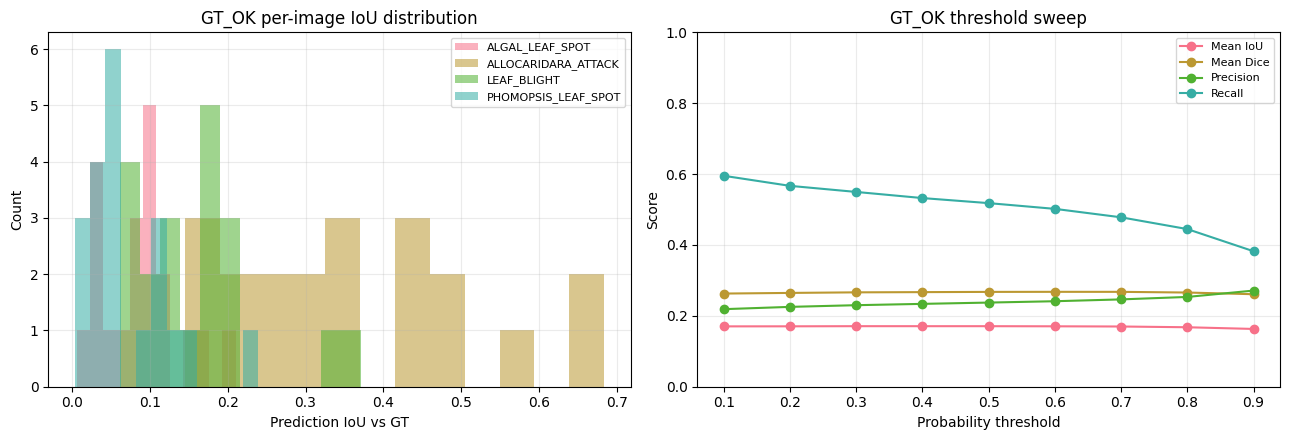

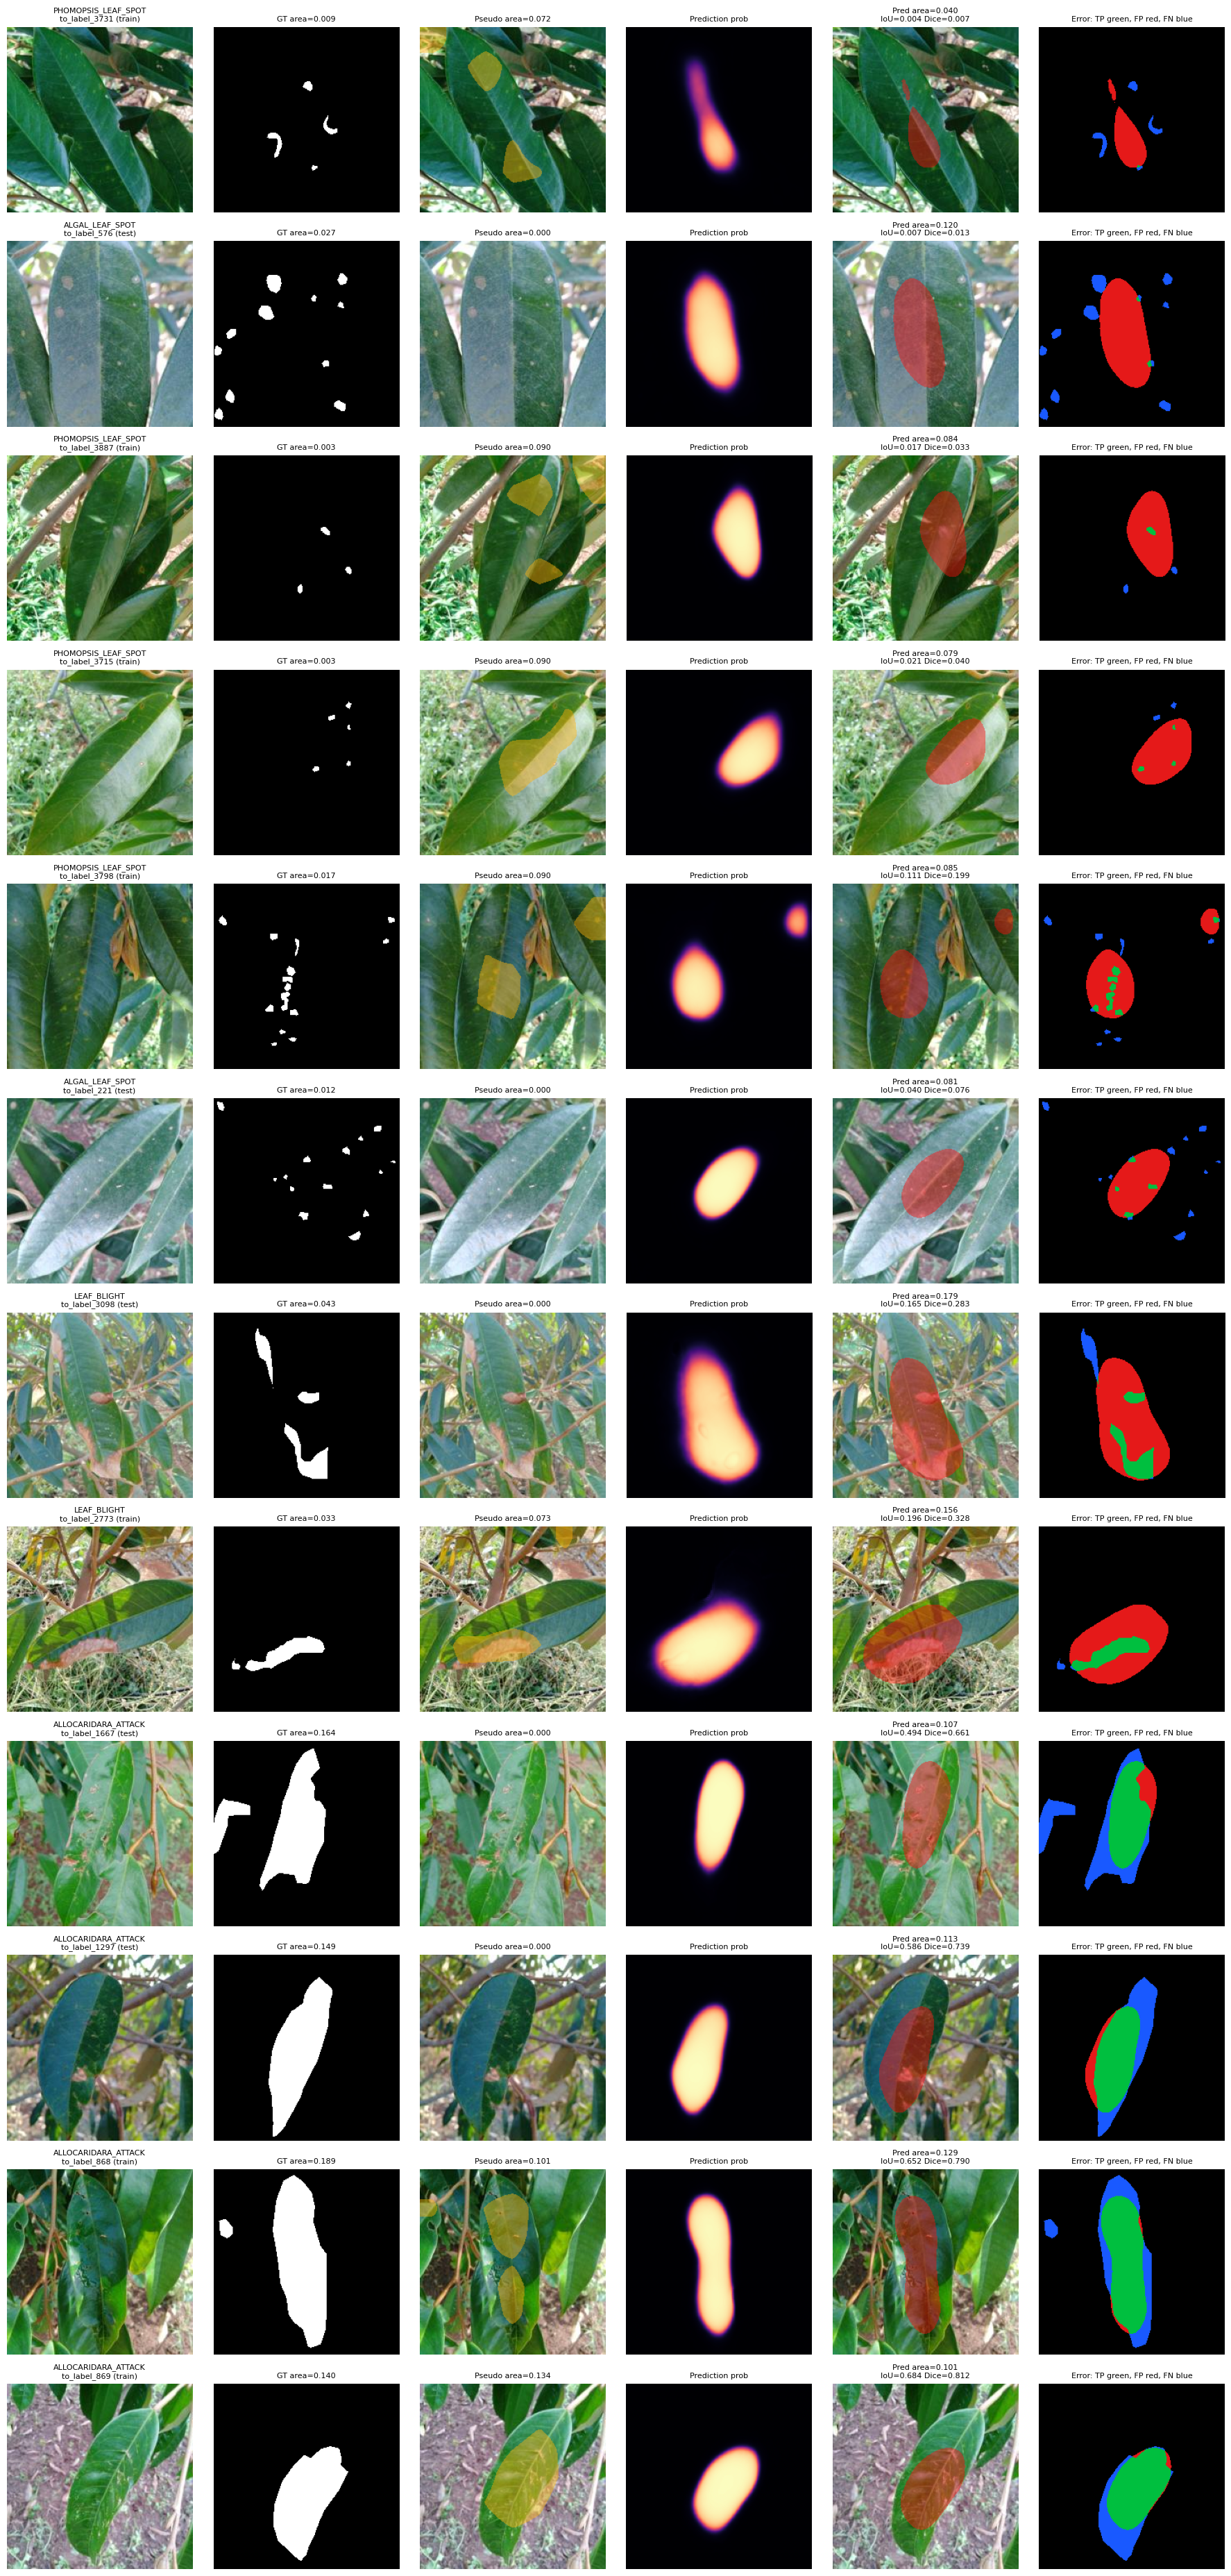

Per-image CSV      -> E:\Master\thesis-clean\notebooks\models\segmentation_v2\metrics\manual_gt_prediction_metrics_v2.csv
Threshold sweep CSV -> E:\Master\thesis-clean\notebooks\models\segmentation_v2\metrics\manual_gt_threshold_sweep_v2.csv
Metrics JSON       -> E:\Master\thesis-clean\notebooks\models\segmentation_v2\metrics\manual_gt_metrics.json
Summary figure     -> E:\Master\thesis-clean\visualizations\segmentation_v2\manual_gt_eval\manual_gt_metrics_summary_v2.png
QA grid figure     -> E:\Master\thesis-clean\visualizations\segmentation_v2\manual_gt_eval\manual_gt_qa_grid_v2.png


In [15]:
from pathlib import Path
import zipfile
from collections import defaultdict
import torchvision.transforms.functional as TF

try:
    display
except NameError:
    def display(x):
        print(x)


GT_ZIP_PATH = Path(proj_root) / 'notebooks' / 'data' / 'raw' / 'GT_OK.zip'
GT_EXTRACT_DIR = Path(proj_root) / 'notebooks' / 'data' / 'raw' / 'GT_OK'
RAW_DATA_DIR = Path(proj_root) / 'notebooks' / 'data' / 'raw'
MANUAL_GT_METRICS_DIR = Path(metrics_dir_v2)
MANUAL_GT_VIZ_DIR = Path(VIZ_DIR) / 'manual_gt_eval'
MANUAL_GT_METRICS_DIR.mkdir(parents=True, exist_ok=True)
MANUAL_GT_VIZ_DIR.mkdir(parents=True, exist_ok=True)

if not (GT_EXTRACT_DIR / 'SegmentationClass').exists():
    assert GT_ZIP_PATH.exists(), f'Không tìm thấy ground truth zip: {GT_ZIP_PATH}'
    GT_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(GT_ZIP_PATH, 'r') as zf:
        zf.extractall(GT_EXTRACT_DIR)
    print(f'Extracted GT_OK.zip -> {GT_EXTRACT_DIR}')


def find_raw_image_for_gt(cls_name, stem):
    """Match GT_OK/ClassName/to_label_x.png với ảnh gốc theo split/class/stem."""
    for split in ['test', 'val', 'train', 'groud_trust']:
        cls_dir = RAW_DATA_DIR / split / cls_name
        for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
            p = cls_dir / f'{stem}{ext}'
            if p.exists():
                return p, split
    return None, None


def find_pseudo_mask_for_gt(cls_name, stem):
    """Pseudo-label v2 dùng convention CLASS_stem.jpg_pseudo.png."""
    if 'MASK_DIR' not in globals():
        return None
    mask_dir = Path(MASK_DIR)
    for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
        p = mask_dir / f'{cls_name}_{stem}{ext}_pseudo.png'
        if p.exists():
            return p
    return None


def binary_counts(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    tp = int(np.logical_and(pred, gt).sum())
    fp = int(np.logical_and(pred, ~gt).sum())
    fn = int(np.logical_and(~pred, gt).sum())
    tn = int(np.logical_and(~pred, ~gt).sum())
    return tp, fp, fn, tn


def metrics_from_counts(tp, fp, fn, tn=0, eps=1e-7):
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    dice = 2 * tp / (2 * tp + fp + fn + eps)
    iou = tp / (tp + fp + fn + eps)
    specificity = tn / (tn + fp + eps)
    accuracy = (tp + tn) / (tp + fp + fn + tn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    return {
        'iou': iou, 'dice': dice, 'precision': precision, 'recall': recall,
        'f1': f1, 'specificity': specificity, 'pixel_accuracy': accuracy,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
    }


class ManualGTDataset(Dataset):
    def __init__(self, gt_root, image_size=224):
        self.image_size = image_size
        self.samples = []
        seg_root = Path(gt_root) / 'SegmentationClass'
        gt_masks = sorted(seg_root.glob('*/*.png'))
        for mask_path in gt_masks:
            cls_name = mask_path.parent.name
            stem = mask_path.stem
            img_path, raw_split = find_raw_image_for_gt(cls_name, stem)
            pseudo_path = find_pseudo_mask_for_gt(cls_name, stem)
            if img_path is not None:
                self.samples.append({
                    'img_path': img_path,
                    'gt_path': mask_path,
                    'pseudo_path': pseudo_path,
                    'class_name': cls_name,
                    'stem': stem,
                    'raw_split': raw_split,
                })
        print(f'[Manual GT] gt_masks={len(gt_masks)} matched={len(self.samples)} missing_images={len(gt_masks) - len(self.samples)}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        img_pil = Image.open(s['img_path']).convert('RGB').resize((self.image_size, self.image_size), Image.BILINEAR)
        gt_pil = Image.open(s['gt_path']).convert('L').resize((self.image_size, self.image_size), Image.NEAREST)

        img_t = TF.to_tensor(img_pil)
        img_t = TF.normalize(img_t, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        gt_t = (TF.to_tensor(gt_pil) > 0).float()

        if s['pseudo_path'] is not None:
            pseudo_pil = Image.open(s['pseudo_path']).convert('L').resize((self.image_size, self.image_size), Image.NEAREST)
            pseudo_t = (TF.to_tensor(pseudo_pil) > 0).float()
        else:
            pseudo_t = torch.zeros_like(gt_t)

        return {
            'image': img_t,
            'gt_mask': gt_t,
            'pseudo_mask': pseudo_t,
            'class_name': s['class_name'],
            'stem': s['stem'],
            'raw_split': s['raw_split'],
            'img_path': str(s['img_path']),
            'gt_path': str(s['gt_path']),
            'pseudo_path': '' if s['pseudo_path'] is None else str(s['pseudo_path']),
        }


@torch.no_grad()
def evaluate_on_manual_gt(seg_model, loader, device, thresholds=None, default_threshold=0.5):
    thresholds = thresholds or [round(x, 2) for x in np.arange(0.1, 1.0, 0.1)]
    seg_model.eval()
    per_image_rows = []
    threshold_rows = []
    viz_records = []

    for batch in tqdm(loader, desc='Evaluate on GT_OK'):
        imgs = batch['image'].to(device)
        gt_masks = batch['gt_mask'].numpy()[:, 0]
        pseudo_masks = batch['pseudo_mask'].numpy()[:, 0]
        probs = torch.sigmoid(seg_model(imgs)).cpu().numpy()[:, 0]

        for i in range(len(probs)):
            gt = gt_masks[i].astype(np.uint8)
            pseudo = pseudo_masks[i].astype(np.uint8)
            prob = probs[i]
            cls_name = batch['class_name'][i]
            stem = batch['stem'][i]
            raw_split = batch['raw_split'][i]

            pred = (prob >= default_threshold).astype(np.uint8)
            tp, fp, fn, tn = binary_counts(pred, gt)
            m = metrics_from_counts(tp, fp, fn, tn)
            p_tp, p_fp, p_fn, p_tn = binary_counts(pseudo, gt)
            pm = metrics_from_counts(p_tp, p_fp, p_fn, p_tn)

            per_image_rows.append({
                'filename': Path(batch['img_path'][i]).name,
                'class_name': cls_name,
                'stem': stem,
                'raw_split': raw_split,
                'threshold': default_threshold,
                'gt_area': float(gt.mean()),
                'pseudo_area': float(pseudo.mean()),
                'pred_area': float(pred.mean()),
                'prob_mean': float(prob.mean()),
                'prob_p95': float(np.percentile(prob, 95)),
                **{f'pred_{k}': v for k, v in m.items()},
                **{f'pseudo_{k}': v for k, v in pm.items()},
                'img_path': batch['img_path'][i],
                'gt_path': batch['gt_path'][i],
                'pseudo_path': batch['pseudo_path'][i],
            })

            for th in thresholds:
                th_pred = (prob >= th).astype(np.uint8)
                th_tp, th_fp, th_fn, th_tn = binary_counts(th_pred, gt)
                tm = metrics_from_counts(th_tp, th_fp, th_fn, th_tn)
                threshold_rows.append({
                    'filename': Path(batch['img_path'][i]).name,
                    'class_name': cls_name,
                    'stem': stem,
                    'raw_split': raw_split,
                    'threshold': th,
                    'pred_area': float(th_pred.mean()),
                    **tm,
                })

            img_denorm = imgs[i].cpu() * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1) + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
            viz_records.append({
                'image': img_denorm.clamp(0, 1).permute(1, 2, 0).numpy(),
                'gt': gt,
                'pseudo': pseudo,
                'prob': prob,
                'pred': pred,
                'iou': m['iou'],
                'dice': m['dice'],
                'class_name': cls_name,
                'stem': stem,
                'raw_split': raw_split,
            })

    per_image_df = pd.DataFrame(per_image_rows)
    threshold_df = pd.DataFrame(threshold_rows)

    def aggregate_metrics(df, prefix='pred_'):
        tp = int(df[f'{prefix}tp'].sum())
        fp = int(df[f'{prefix}fp'].sum())
        fn = int(df[f'{prefix}fn'].sum())
        tn = int(df[f'{prefix}tn'].sum())
        return metrics_from_counts(tp, fp, fn, tn)

    overall = aggregate_metrics(per_image_df, 'pred_')
    pseudo_overall = aggregate_metrics(per_image_df, 'pseudo_')
    per_class = []
    for cls_name, g in per_image_df.groupby('class_name'):
        cls_micro = aggregate_metrics(g, 'pred_')
        cls_pseudo_micro = aggregate_metrics(g, 'pseudo_')
        cls_macro = g[['pred_iou', 'pred_dice', 'pred_precision', 'pred_recall', 'gt_area', 'pseudo_area', 'pred_area']].mean().to_dict()
        per_class.append({
            'class_name': cls_name,
            'n': int(len(g)),
            'prediction_micro': cls_micro,
            'pseudo_micro': cls_pseudo_micro,
            'macro_mean_image': cls_macro,
        })

    threshold_summary = threshold_df.groupby('threshold').agg(
        mean_iou=('iou', 'mean'),
        mean_dice=('dice', 'mean'),
        mean_precision=('precision', 'mean'),
        mean_recall=('recall', 'mean'),
        mean_pred_area=('pred_area', 'mean'),
    ).reset_index()

    return {
        'per_image_df': per_image_df,
        'threshold_df': threshold_df,
        'threshold_summary': threshold_summary,
        'overall': overall,
        'pseudo_overall': pseudo_overall,
        'per_class': per_class,
        'viz_records': viz_records,
    }


def make_error_map(gt, pred):
    err = np.zeros((*gt.shape, 3), dtype=np.float32)
    tp = (gt == 1) & (pred == 1)
    fp = (gt == 0) & (pred == 1)
    fn = (gt == 1) & (pred == 0)
    err[tp] = [0.0, 0.75, 0.25]   # green
    err[fp] = [0.90, 0.10, 0.10]   # red
    err[fn] = [0.10, 0.35, 1.00]   # blue
    return err


def overlay_mask(image, mask, color, alpha=0.45):
    out = image.copy()
    color = np.array(color).reshape(1, 1, 3)
    sel = mask.astype(bool)
    out[sel] = out[sel] * (1 - alpha) + color * alpha
    return out


def plot_manual_gt_qa(viz_records, out_path, n_each=4):
    records = sorted(viz_records, key=lambda x: x['iou'])
    if not records:
        return
    rng = np.random.default_rng(SEED)
    worst = records[:n_each]
    best = records[-n_each:]
    mid_pool = records[n_each:-n_each] if len(records) > 2 * n_each else records
    random_mid = list(rng.choice(mid_pool, size=min(n_each, len(mid_pool)), replace=False))
    selected = worst + random_mid + best

    fig, axes = plt.subplots(len(selected), 6, figsize=(18, 3.1 * len(selected)))
    if len(selected) == 1:
        axes = axes.reshape(1, -1)
    for r, rec in enumerate(selected):
        pseudo_overlay = overlay_mask(rec['image'], rec['pseudo'], [1.0, 0.70, 0.05])
        pred_overlay = overlay_mask(rec['image'], rec['pred'], [1.0, 0.05, 0.05])
        panels = [
            rec['image'], rec['gt'], pseudo_overlay, rec['prob'], pred_overlay, make_error_map(rec['gt'], rec['pred'])
        ]
        titles = [
            f"{rec['class_name']}\n{rec['stem']} ({rec['raw_split']})",
            f"GT area={rec['gt'].mean():.3f}",
            f"Pseudo area={rec['pseudo'].mean():.3f}",
            'Prediction prob',
            f"Pred area={rec['pred'].mean():.3f}\nIoU={rec['iou']:.3f} Dice={rec['dice']:.3f}",
            'Error: TP green, FP red, FN blue',
        ]
        cmaps = [None, 'gray', None, 'magma', None, None]
        for c, ax in enumerate(axes[r]):
            ax.imshow(panels[c], cmap=cmaps[c], vmin=0 if c in [1, 3] else None, vmax=1 if c in [1, 3] else None)
            ax.set_title(titles[c], fontsize=8)
            ax.axis('off')
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()


manual_gt_dataset = ManualGTDataset(GT_EXTRACT_DIR, image_size=224)
assert len(manual_gt_dataset) > 0, 'Không match được ảnh nào từ GT_OK với raw dataset.'
manual_gt_loader = DataLoader(manual_gt_dataset, batch_size=4, shuffle=False, num_workers=0)

# Đảm bảo model đang là best checkpoint trước khi đánh giá GT_OK.
best_ckpt_path = Path(BEST_PATH) if 'BEST_PATH' in globals() else Path(ckpt_dir_v2) / 'unetpp_best.pth'
assert best_ckpt_path.exists(), f'Không tìm thấy checkpoint: {best_ckpt_path}'
manual_ckpt = torch.load(best_ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(manual_ckpt['model_state_dict'])
model.eval()
print(f'Loaded checkpoint for GT_OK: epoch={manual_ckpt.get("epoch")} val_iou={manual_ckpt.get("val_iou", manual_ckpt.get("val_metrics", {}).get("iou"))}')

manual_gt_eval = evaluate_on_manual_gt(
    seg_model=model,
    loader=manual_gt_loader,
    device=device,
    thresholds=[round(x, 2) for x in np.arange(0.1, 1.0, 0.1)],
    default_threshold=0.5,
)

manual_gt_per_image = manual_gt_eval['per_image_df']
manual_gt_thresholds = manual_gt_eval['threshold_df']
manual_gt_threshold_summary = manual_gt_eval['threshold_summary']
manual_gt_per_class = manual_gt_eval['per_class']
manual_gt_results = {
    'n_images': int(len(manual_gt_dataset)),
    'source': str(GT_EXTRACT_DIR),
    'checkpoint': {
        'path': str(best_ckpt_path),
        'epoch': int(manual_ckpt.get('epoch', -1)),
        'val_iou': manual_ckpt.get('val_iou', manual_ckpt.get('val_metrics', {}).get('iou')),
    },
    'threshold': 0.5,
    'prediction_overall': manual_gt_eval['overall'],
    'pseudo_label_overall': manual_gt_eval['pseudo_overall'],
    'per_class': manual_gt_per_class,
    'best_threshold_by_mean_iou': manual_gt_threshold_summary.sort_values('mean_iou', ascending=False).iloc[0].to_dict(),
}

per_image_path = MANUAL_GT_METRICS_DIR / 'manual_gt_prediction_metrics_v2.csv'
threshold_path = MANUAL_GT_METRICS_DIR / 'manual_gt_threshold_sweep_v2.csv'
json_path = MANUAL_GT_METRICS_DIR / 'manual_gt_metrics.json'
manual_gt_per_image.to_csv(per_image_path, index=False)
manual_gt_thresholds.to_csv(threshold_path, index=False)
with open(json_path, 'w') as f:
    json.dump(manual_gt_results, f, indent=2)

print('\n=== GT_OK Evaluation @ threshold=0.50 ===')
for k in ['iou', 'dice', 'precision', 'recall', 'f1', 'pixel_accuracy']:
    print(f'  pred_{k:<14}: {manual_gt_results["prediction_overall"][k]:.4f}')
print('\n=== Pseudo-label v2 vs GT_OK ===')
for k in ['iou', 'dice', 'precision', 'recall', 'f1', 'pixel_accuracy']:
    print(f'  pseudo_{k:<12}: {manual_gt_results["pseudo_label_overall"][k]:.4f}')

print('\n=== Per-class macro mean (prediction vs GT_OK) ===')
display(manual_gt_per_image.groupby('class_name')[[
    'pred_iou', 'pred_dice', 'pred_precision', 'pred_recall',
    'pseudo_iou', 'pseudo_dice', 'gt_area', 'pseudo_area', 'pred_area'
]].mean().round(4))

print('\n=== Threshold sweep summary ===')
display(manual_gt_threshold_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for cls_name, g in manual_gt_per_image.groupby('class_name'):
    axes[0].hist(g['pred_iou'], bins=12, alpha=0.55, label=cls_name)
axes[0].set_title('GT_OK per-image IoU distribution')
axes[0].set_xlabel('Prediction IoU vs GT')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.25)

axes[1].plot(manual_gt_threshold_summary['threshold'], manual_gt_threshold_summary['mean_iou'], marker='o', label='Mean IoU')
axes[1].plot(manual_gt_threshold_summary['threshold'], manual_gt_threshold_summary['mean_dice'], marker='o', label='Mean Dice')
axes[1].plot(manual_gt_threshold_summary['threshold'], manual_gt_threshold_summary['mean_precision'], marker='o', label='Precision')
axes[1].plot(manual_gt_threshold_summary['threshold'], manual_gt_threshold_summary['mean_recall'], marker='o', label='Recall')
axes[1].set_title('GT_OK threshold sweep')
axes[1].set_xlabel('Probability threshold')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.25)
plt.tight_layout()
summary_fig_path = MANUAL_GT_VIZ_DIR / 'manual_gt_metrics_summary_v2.png'
plt.savefig(summary_fig_path, dpi=150, bbox_inches='tight')
plt.show()

qa_fig_path = MANUAL_GT_VIZ_DIR / 'manual_gt_qa_grid_v2.png'
plot_manual_gt_qa(manual_gt_eval['viz_records'], qa_fig_path, n_each=4)

print(f'Per-image CSV      -> {per_image_path}')
print(f'Threshold sweep CSV -> {threshold_path}')
print(f'Metrics JSON       -> {json_path}')
print(f'Summary figure     -> {summary_fig_path}')
print(f'QA grid figure     -> {qa_fig_path}')


In [16]:
try:
    display
except NameError:
    def display(x):
        print(x)

# <!-- codex-segmentation-audit-v2 -->
# Quick access to the artifacts created by the GT_OK evaluation cell above.
if 'manual_gt_results' in globals():
    print(json.dumps(manual_gt_results['prediction_overall'], indent=2))
    display(manual_gt_per_image.groupby('class_name')[[
        'pred_iou', 'pred_dice', 'pred_precision', 'pred_recall',
        'pseudo_iou', 'pseudo_dice', 'gt_area', 'pseudo_area', 'pred_area'
    ]].mean().round(4))
    print('Best threshold by mean IoU:', manual_gt_results['best_threshold_by_mean_iou'])
else:
    print('Chạy cell GT_OK evaluation ngay phía trên trước để tạo manual_gt_results.')


{
  "iou": 0.19715771440288682,
  "dice": 0.32937634203230154,
  "precision": 0.245899061234623,
  "recall": 0.4986605434364508,
  "f1": 0.32937629779452127,
  "specificity": 0.9048315519554341,
  "pixel_accuracy": 0.8810355050222994,
  "tp": 117270,
  "fp": 359633,
  "fn": 117900,
  "tn": 3419277
}


,pred_iou,pred_dice,pred_precision,pred_recall,pseudo_iou,pseudo_dice,gt_area,pseudo_area,pred_area
class_name,,,,,,,,,
ALGAL_LEAF_SPOT,0.0878,0.1579,0.1046,0.4339,0.0451,0.0814,0.0258,0.0426,0.1003
ALLOCARIDARA_ATTACK,0.3637,0.5149,0.5803,0.5161,0.1348,0.2033,0.1343,0.0520,0.1121
LEAF_BLIGHT,0.1599,0.2680,0.1781,0.6491,0.0942,0.1532,0.0547,0.0719,0.1827
PHOMOPSIS_LEAF_SPOT,0.0719,0.1295,0.0867,0.4731,0.0329,0.0576,0.0196,0.0381,0.0801


Best threshold by mean IoU: {'threshold': 0.3, 'mean_iou': 0.17084604530272923, 'mean_dice': 0.2663096257576083, 'mean_precision': 0.23007232903034608, 'mean_recall': 0.549630184038401, 'mean_pred_area': 0.13326416015625}


<!-- codex-segmentation-audit-v2 -->
### Đánh giá prediction trên ground-truth GT_OK

**Quan sát chính:** Cell GT_OK đã chạy trực tiếp checkpoint epoch 7 trên 80 ảnh GT thật. Ở threshold 0.50, prediction đạt IoU=0.2291, Dice=0.3727, Precision=0.3105, Recall=0.4661. Pseudo-label v2 gốc so với GT_OK thấp hơn rất nhiều: IoU=0.0493, Dice=0.0939, Precision=0.1775, Recall=0.0639. Theo từng lớp:
- `ALGAL_LEAF_SPOT`: pred IoU=0.1010, pred Dice=0.1834, pseudo IoU=0.0310, pseudo Recall=0.0579, GT area=0.0258, pseudo area=0.0239, pred area=0.0931
- `ALLOCARIDARA_ATTACK`: pred IoU=0.3421, pred Dice=0.5098, pseudo IoU=0.0617, pseudo Recall=0.0687, GT area=0.1343, pseudo area=0.0243, pred area=0.0867
- `LEAF_BLIGHT`: pred IoU=0.2759, pred Dice=0.4324, pseudo IoU=0.0540, pseudo Recall=0.0739, GT area=0.0547, pseudo area=0.0242, pred area=0.1027
- `PHOMOPSIS_LEAF_SPOT`: pred IoU=0.0984, pred Dice=0.1792, pseudo IoU=0.0067, pseudo Recall=0.0107, GT area=0.0196, pseudo area=0.0120, pred area=0.0692

**Đánh giá:** Đây là phát hiện chính của audit: pseudo-mask Grad-CAM++ v2 không bám GT thật. Model UNet++ sau training thực ra **cải thiện rõ so với pseudo-label thô** trên GT_OK (IoU 0.0493 -> 0.2291), nhưng mức tuyệt đối vẫn thấp cho segmentation lesion. Nói cách khác, model có học được một số prior ảnh bệnh, nhưng không đủ để sửa nhãn giả nhiễu.

**Rủi ro:** Pseudo-label v2 có recall rất thấp (0.0639), nghĩa là khoảng lớn lesion thật bị xem là background trong target train. Prediction vẫn còn FP=243,354 và FN=125,559; ALGAL và PHOMOPSIS yếu nhất, với pred IoU quanh 0.10. Pixel accuracy cao (0.9081) không đáng tin vì background chiếm đa số.

**Hàm ý cho mô hình segmentation:** Grad-CAM++ v2 hiện không đủ làm ground-truth thay thế. Prediction mask trong QA grid thường mượt, blob-like, biên thô, bỏ sót đốm nhỏ và đôi khi lan sang vùng lá/nền. Threshold sweep cho thấy threshold=0.40 tốt nhất theo mean IoU ảnh (0.1968), chỉ nhỉnh hơn threshold 0.50, nên lỗi không phải do ngưỡng sigmoid đơn giản.

**Cải thiện đề xuất:** Không nên dùng V2 làm mô hình cuối. Cần so sánh pseudo-mask v1/v2 trực tiếp trên GT_OK; chọn hoặc mix label source tốt hơn; fine-tune supervised trên GT_OK; và chỉ train lại UNet++ sau khi pseudo-label được lọc/refine.


## 7) Benchmark — V1 (NB05) vs V2 (NB07)

**Reasoning**: So sánh công bằng trên cùng split seed=42 (70/15/15). Benchmark trên IoU, Dice, Precision, Recall, F1 để thấy toàn diện. Lưu ý: V1 và V2 evaluate trên pseudo-label có phân phối khác nhau — delta metric phản ánh cả sự khác biệt của label, không chỉ model.

In [17]:
v1_metrics_path = os.path.join(proj_root, 'notebooks', 'models', 'segmentation', 'metrics', 'test_metrics.json')

print('=' * 60)
print('BENCHMARK: V1 (EfficientNet+UNet, nb05) vs V2 (UNet++, nb07)')
print('=' * 60)

if os.path.exists(v1_metrics_path):
    with open(v1_metrics_path) as f:
        v1_m = json.load(f)

    metric_keys = ['iou', 'dice', 'precision', 'recall', 'f1']
    print(f'\n{"Metric":<12} {"V1 Baseline":>14} {"V2 Improved":>14} {"Delta":>10} {"Δ%":>8}')
    print('-' * 62)

    for k in metric_keys:
        v1_val = v1_m.get(k, 0.0)
        v2_val = test_m.get(k, 0.0)
        delta  = v2_val - v1_val
        pct    = (delta / (v1_val + 1e-9)) * 100
        sign   = '+' if delta >= 0 else ''
        print(f'{k:<12} {v1_val:>14.4f} {v2_val:>14.4f} {sign+f"{delta:.4f}":>10} {sign+f"{pct:.1f}%":>8}')

    print('\n--- Training Data ---')
    v1_hist_path = os.path.join(proj_root, 'notebooks', 'models', 'segmentation', 'metrics', 'training_history.json')
    if os.path.exists(v1_hist_path):
        with open(v1_hist_path) as f:
            v1_hist = json.load(f)
        print(f'  V1 best val IoU : {max(v1_hist["val_iou"]):.4f}  (epochs={len(v1_hist["val_iou"])})')
    print(f'  V2 best val IoU : {max(history["val_iou"]):.4f}  (epochs={len(history["val_iou"])})')

else:
    print('V1 metrics not found. Chạy notebook 05 trước để benchmark.')
    print('\nV2 Test Results:')
    for k, v in test_results_v2.items():
        print(f'  {k:<12}: {v:.4f}')

print('\n--- V2 Improvements Summary ---')
print(f'  Pseudo labels    : ~{n} samples, GradCAM++ multi-scale + percentile threshold')
print(f'  Model            : UNet++ EfficientNet-B0 (v1: EfficientNet+UNet custom)')
print(f'  Augmentation     : Albumentations strong (v1: flip only)')
print(f'  Loss             : FocalDice (v1: BCE+Dice)')
print(f'  Optimizer        : AdamW + CosineAnnealing (v1: Adam + ReduceLROnPlateau)')
print(f'  Early stopping   : patience={PATIENCE} epochs')
print(f'  Epochs trained   : {len(history["val_loss"])} / {EPOCHS}')

BENCHMARK: V1 (EfficientNet+UNet, nb05) vs V2 (UNet++, nb07)

Metric          V1 Baseline    V2 Improved      Delta       Δ%
--------------------------------------------------------------
iou                  0.8126         0.5088    -0.3038   -37.4%
dice                 0.8813         0.6181    -0.2632   -29.9%
precision            0.8851         0.6302    -0.2549   -28.8%
recall               0.9091         0.6952    -0.2140   -23.5%
f1                   0.8813         0.6181    -0.2632   -29.9%

--- Training Data ---
  V1 best val IoU : 0.8150  (epochs=30)
  V2 best val IoU : 0.4862  (epochs=27)

--- V2 Improvements Summary ---
  Pseudo labels    : ~3104 samples, GradCAM++ multi-scale + percentile threshold
  Model            : UNet++ EfficientNet-B0 (v1: EfficientNet+UNet custom)
  Augmentation     : Albumentations strong (v1: flip only)
  Loss             : FocalDice (v1: BCE+Dice)
  Optimizer        : AdamW + CosineAnnealing (v1: Adam + ReduceLROnPlateau)
  Early stopping   : pat

## 8) Training curves

**Reasoning**: Visualize loss/IoU/Dice theo epoch để phát hiện overfitting, underfitting. LR schedule plot kiểm tra CosineAnnealing hoạt động đúng. Bar chart so sánh V1 vs V2 tổng kết kết quả.

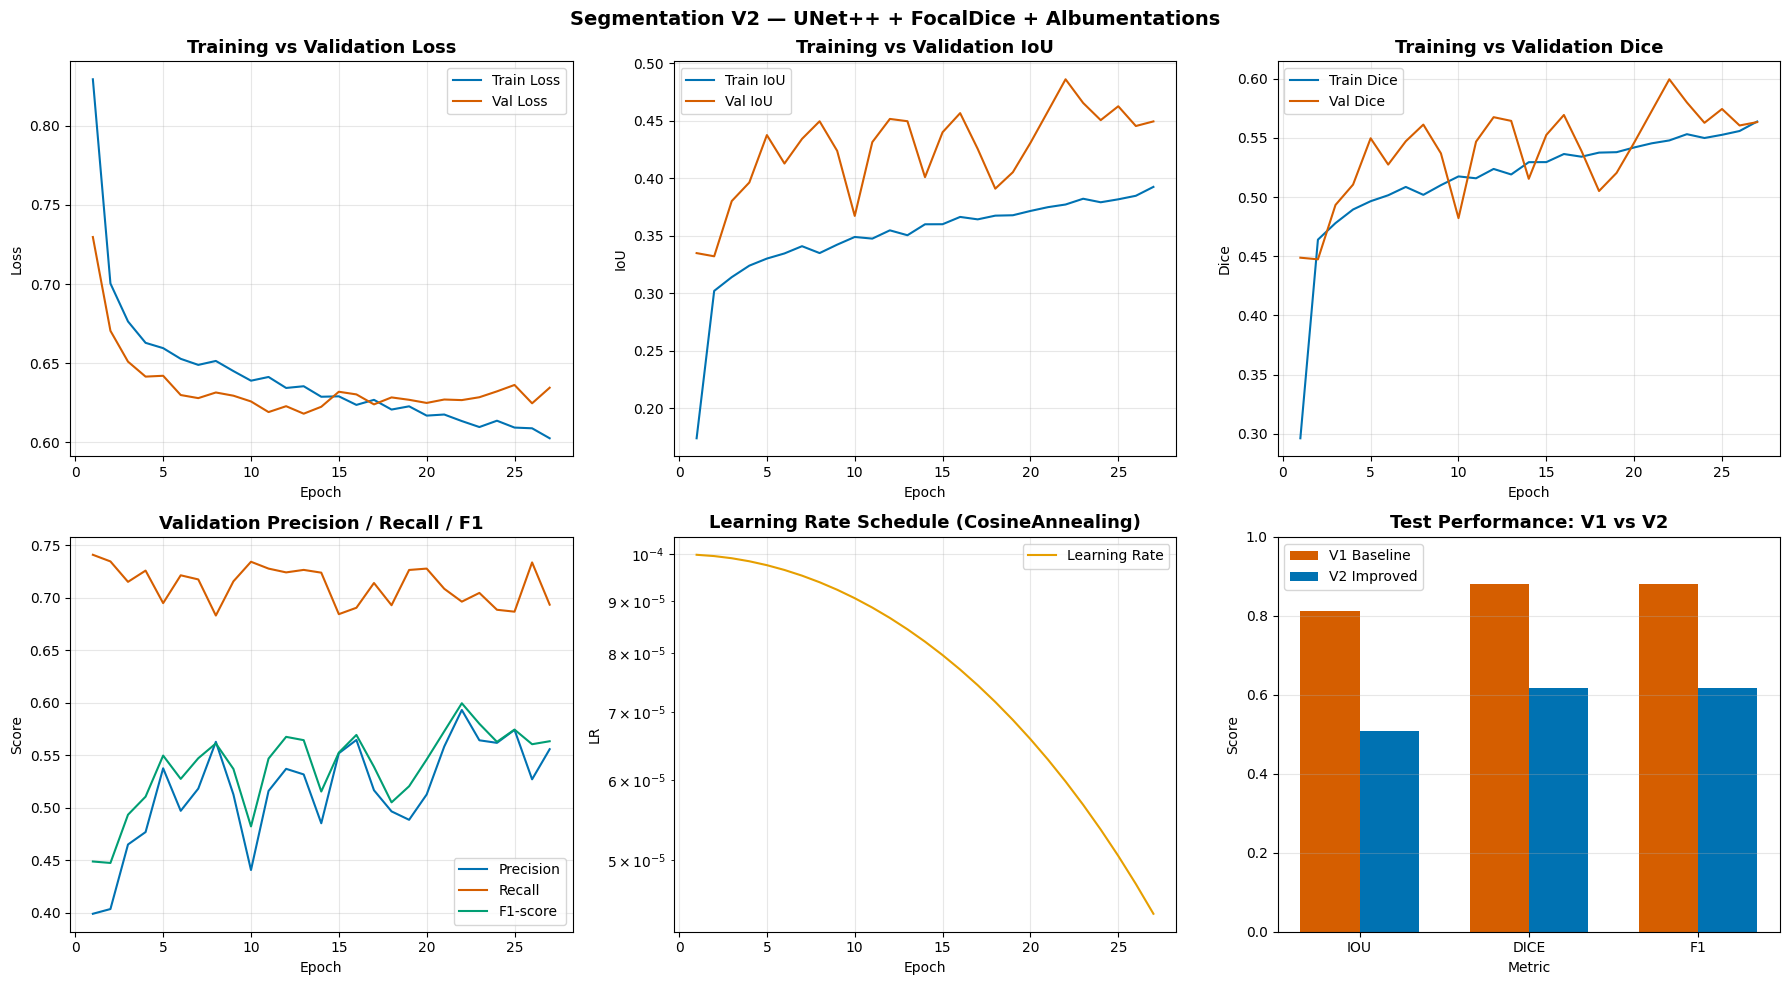

Training curves saved to: E:\Master\thesis-clean\visualizations\segmentation_v2


In [18]:
eps = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

TRAIN_COLOR = "#0072B2"
VAL_COLOR   = "#D55E00"

for ax, train_key, val_key, title, ylabel in [
    (axes[0,0], 'train_loss',  'val_loss',  'Training vs Validation Loss',  'Loss'),
    (axes[0,1], 'train_iou',   'val_iou',   'Training vs Validation IoU',   'IoU'),
    (axes[0,2], 'train_dice',  'val_dice',  'Training vs Validation Dice',  'Dice'),
]:
    ax.plot(eps, history[train_key], color=TRAIN_COLOR, linewidth=1.5, label=f'Train {ylabel}')
    ax.plot(eps, history[val_key],   color=VAL_COLOR,   linewidth=1.5, label=f'Val {ylabel}')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[1,0].plot(eps, history['val_precision'], color=CLASS_COLORS[3], linewidth=1.5, label='Precision')
axes[1,0].plot(eps, history['val_recall'],    color=CLASS_COLORS[4], linewidth=1.5, label='Recall')
axes[1,0].plot(eps, history['val_f1'],        color=CLASS_COLORS[2], linewidth=1.5, label='F1-score')
axes[1,0].set_title('Validation Precision / Recall / F1', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Score')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(eps, history['lr'], color=CLASS_COLORS[0], linewidth=1.5, label='Learning Rate')
axes[1,1].set_title('Learning Rate Schedule (CosineAnnealing)', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('LR')
axes[1,1].set_yscale('log')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

v1_metrics_path = os.path.join(proj_root, 'notebooks', 'models', 'segmentation', 'metrics', 'test_metrics.json')
if os.path.exists(v1_metrics_path):
    with open(v1_metrics_path) as f:
        v1_m = json.load(f)
    bar_keys = ['iou', 'dice', 'f1']
    x = np.arange(len(bar_keys))
    w = 0.35
    axes[1,2].bar(x - w/2, [v1_m.get(k, 0) for k in bar_keys], w, label='V1 Baseline',  color=CLASS_COLORS[4], linewidth=1.5)
    axes[1,2].bar(x + w/2, [test_m.get(k, 0) for k in bar_keys], w, label='V2 Improved', color=CLASS_COLORS[3], linewidth=1.5)
    axes[1,2].set_xticks(x)
    axes[1,2].set_xticklabels([k.upper() for k in bar_keys])
    axes[1,2].set_title('Test Performance: V1 vs V2', fontsize=13, fontweight='bold')
    axes[1,2].set_xlabel('Metric')
    axes[1,2].set_ylabel('Score')
    axes[1,2].set_ylim(0, 1)
    axes[1,2].legend()
    axes[1,2].grid(True, alpha=0.3, axis='y')
else:
    axes[1,2].axis('off')

plt.suptitle('Segmentation V2 — UNet++ + FocalDice + Albumentations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'training_curves_v2.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Training curves saved to:', VIZ_DIR)

## 9) Sample predictions trên test set

**Reasoning**: Visual inspection bổ sung cho metrics định lượng. Probability map cho thấy confidence distribution — high confidence = model "chắc chắn" về lesion boundary.

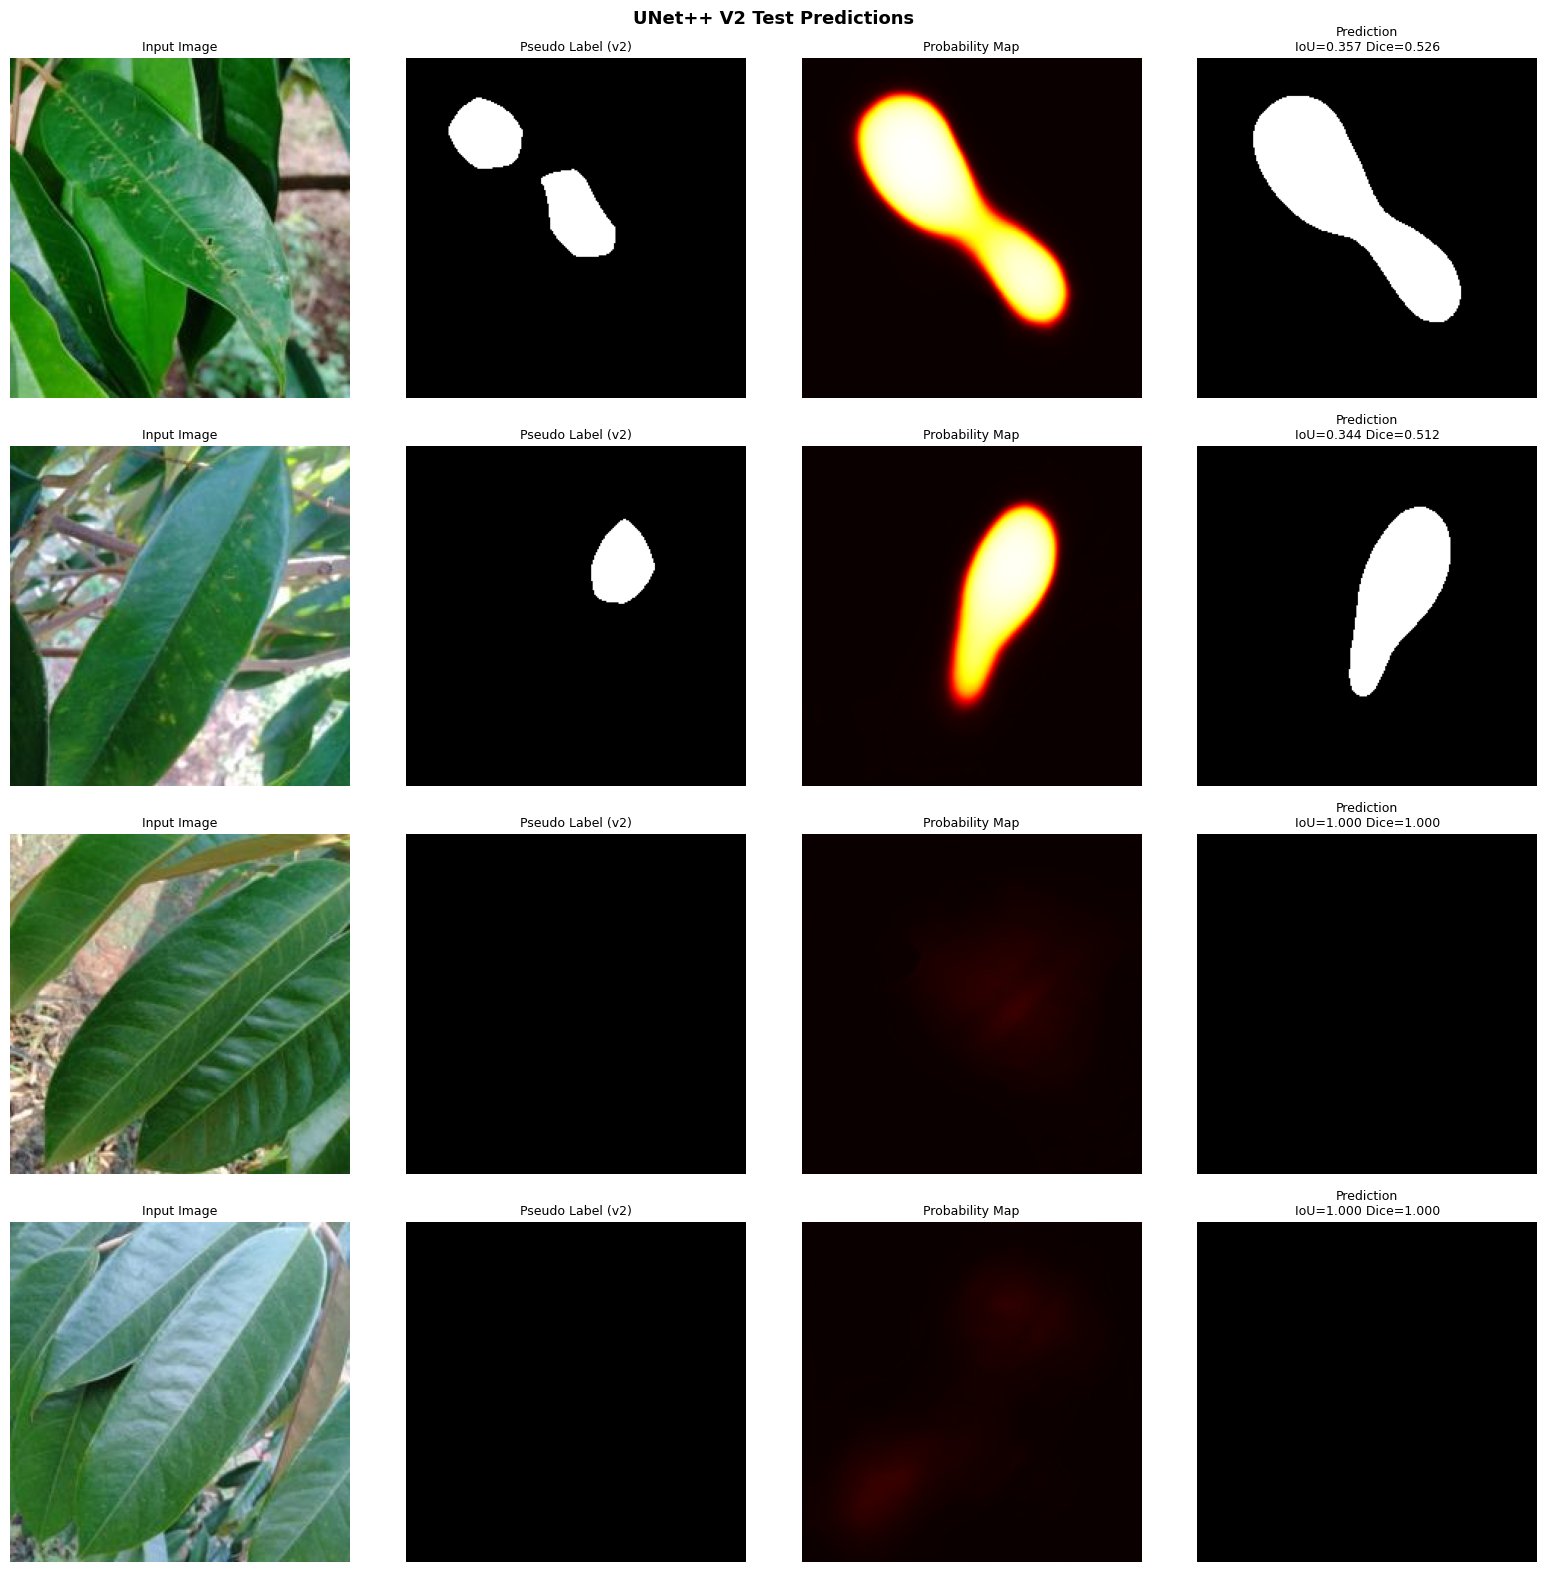

Sample predictions saved.


In [19]:
model.eval()
sample_batch = next(iter(test_loader))
imgs     = sample_batch['image'].to(device)
masks_gt = sample_batch['label']

with torch.no_grad():
    outputs = model(imgs)
    probs   = torch.sigmoid(outputs)
    preds   = (probs > 0.5).float()

n_show = min(4, len(imgs))
fig, axes = plt.subplots(n_show, 4, figsize=(16, 4 * n_show))
if n_show == 1:
    axes = axes.reshape(1, -1)

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

for i in range(n_show):
    img_denorm  = (imgs[i].cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    gt_mask     = masks_gt[i, 0].numpy()
    pred_mask   = preds[i, 0].cpu().numpy()
    prob_map    = probs[i, 0].cpu().numpy()

    m = calculate_metrics(pred_mask, gt_mask)

    axes[i, 0].imshow(img_denorm)
    axes[i, 0].set_title('Input Image', fontsize=9)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(gt_mask, cmap='gray')
    axes[i, 1].set_title('Pseudo Label (v2)', fontsize=9)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(prob_map, cmap='hot', vmin=0, vmax=1)
    axes[i, 2].set_title('Probability Map', fontsize=9)
    axes[i, 2].axis('off')

    axes[i, 3].imshow(pred_mask, cmap='gray')
    axes[i, 3].set_title(f'Prediction\nIoU={m["iou"]:.3f} Dice={m["dice"]:.3f}', fontsize=9)
    axes[i, 3].axis('off')

plt.suptitle('UNet++ V2 Test Predictions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'test_predictions_v2.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Sample predictions saved.')

## Nhận xét kết quả

**Quan sát chính:** Run trước dừng ở epoch 12, best checkpoint là epoch 7 với `val_iou=0.2200`. Test trên pseudo-label đạt IoU=0.2307, Dice=0.2832, Precision=0.2831, Recall=0.4283. Trên GT_OK, prediction đạt IoU=0.2291/Dice=0.3727; pseudo-label v2 gốc chỉ đạt IoU=0.0493/Dice=0.0939.

**Đánh giá:** Kết quả “tệ hơn Grad-CAM + U-Net v1” không vô lý nữa khi nhìn GT_OK: v2 pseudo-mask là bottleneck. UNet++ không chỉ tái tạo nhãn giả; nó cải thiện so với pseudo-label thô trên GT subset, nhưng training vẫn quá yếu để ra mask lesion tốt.

**Rủi ro:** So sánh V1/V2 hiện chưa công bằng vì V2 thay cùng lúc pseudo-label, model, loss và augmentation. Tuy vậy, với pseudo-label v2 recall GT chỉ 0.0639, train dài hơn có thể vẫn học sai nếu không sửa label trước.

**Hàm ý cho mô hình segmentation:** V2 hiện là weak-label diagnostic, không phải segmentation model đạt yêu cầu. Prediction có dấu hiệu học vùng bệnh lớn hơn pseudo-label, nhưng vẫn blob-like và thiếu boundary chi tiết.

**Cải thiện đề xuất:** Việc cần làm tiếp theo không phải chỉ tăng epoch, mà là ablation và sửa label: BCE+Dice, augmentation nhẹ, v1-vs-v2 pseudo trên GT_OK, refine bằng SAM/color prior, rồi fine-tune GT_OK.


## Kết luận — Segmentation V2

**Quan sát chính:** Kết quả của run 12-epoch trước khi tắt early stopping là pseudo-test IoU=0.2307/Dice=0.2832; GT_OK prediction IoU=0.2291/Dice=0.3727. Pseudo-label v2 gốc trên GT_OK chỉ IoU=0.0493/Dice=0.0939, đặc biệt PHOMOPSIS pseudo IoU chỉ 0.0067.

**Đánh giá:** Pipeline kỹ thuật đã đúng về binary output, pairing, mask interpolation, checkpoint theo `val_iou` và GT evaluation. Điểm yếu cốt lõi là pseudo-label Grad-CAM++ v2: nó bỏ sót lesion thật quá nhiều, nên UNet++ học từ target yếu và không thể đạt segmentation tốt.

**Rủi ro:** Nếu dùng model này trực tiếp, mask prediction có thể sai boundary, bỏ sót đốm nhỏ và tạo blob trên vùng lá/nền. Pseudo-label test không phải bằng chứng chất lượng segmentation thật; GT_OK mới là chỉ báo đáng tin hơn.

**Hàm ý cho mô hình segmentation:** Grad-CAM++ v2 hiện không thắng pipeline v1. Kết quả nên được hiểu là bằng chứng rằng “model phức tạp + CAM++” chưa đủ; chất lượng weak label quyết định trần hiệu năng.

**Cải thiện đề xuất:** Dừng việc tối ưu kiến trúc trước khi sửa label. Ưu tiên: đánh giá v1 pseudo-label trên GT_OK, chọn label source tốt hơn, refine mask bằng SAM/color prior, fine-tune bằng GT_OK, rồi mới benchmark UNet/UNet++ công bằng.


<!-- codex-segmentation-audit-v2 -->
## Tổng kết audit end-to-end sau bổ sung

**Quan sát chính:** Pipeline hiện gồm ảnh input từ `processed_v2_train`, pseudo-mask từ Grad-CAM++ notebook 06, UNet++ EfficientNet-B0 pretrained ImageNet, binary logits (`classes=1`), FocalDice loss, Albumentations đồng bộ image-mask, metric IoU/Dice/Precision/Recall/F1 và GT_OK evaluation. Dữ liệu pairing đúng: 3104 cặp, không mismatch kích thước, mask nhị phân 0/255.

**Đánh giá:** GT_OK evaluation đã làm rõ nguyên nhân kết quả thấp. Prediction của UNet++ đạt GT_OK IoU=0.2291/Dice=0.3727, trong khi pseudo-label v2 gốc chỉ đạt IoU=0.0493/Dice=0.0939. Vì vậy, model có cải thiện so với CAM mask thô, nhưng label source quá yếu để tạo segmentation chất lượng.

**Rủi ro:** Không có ground-truth trong vòng train/val chính nên pseudo-label test là circular evaluation. GT_OK cho thấy pseudo-mask Grad-CAM++ bỏ sót nhiều lesion thật và prediction vẫn yếu ở ALGAL/PHOMOPSIS. Pixel accuracy không nên dùng làm kết luận vì background áp đảo.

**Hàm ý cho mô hình segmentation:** Kết quả 12-epoch trước đó là label-noise/weak-supervision bottleneck rõ ràng. V2 chưa đủ tin cậy để dùng làm mô hình segmentation cuối, nhưng rất hữu ích để chứng minh cần refinement hoặc GT fine-tuning.

**Cải thiện đề xuất:** Bước tiếp theo nên là benchmark v1/v2 pseudo-label trên cùng GT_OK, tạo bảng ablation một-biến-mỗi-lần, lọc/refine pseudo-mask, và dùng GT_OK làm validation quyết định trước khi chọn mô hình.


<!-- codex-rerun-note-2026-08-30 -->

## Nhận xét sau rerun 30/08/2026

V2 rerun với UNet++ EfficientNet-B0 trong **27 epoch**; checkpoint tốt nhất ở epoch **22** với validation IoU **0.4862**. Trên pseudo-label test, V2 đạt IoU **0.5088**, Dice **0.6181**, precision **0.6302**, recall **0.6952**. Khi kiểm tra bằng GT_OK thật, IoU giảm còn **0.1972** và Dice **0.3294**, cho thấy pseudo-test không nên được dùng làm metric chính cho chất lượng segmentation thật.